In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
from matplotlib import pyplot as plt

# --! import KIND framework files --!

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'kind-detuning-meas',
        '--data_dir', '../../data/kalman',
        '--data_file', 'tesla_meas',
        '--data_nsample', '144',
        '--data_train_size', '0.8',
        '--data_test_size', '0.5',
        '--target_ndim', '1',

        '--feature_dim', '0,1',
        '--mask_dim', '2',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '32',
        '--learning_rate', '0.001',
        '--weight_decay', '0.00001',
        '--nepoch', '300',
        '--patience', '30',
        '--checkpoints', '../../models/kalman',

        '--seg_nsample_stat', '48',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"sin": 5, "cos": 5}',
        '--nneuron_stat', '128',
        '--nlayer_stat', '3',
        '--nneuron_trans', '128',
        '--nlayer_trans', '3',
    ]
)

dataset = utils_data.dataset_factory().create_dataset(args)
model = kind.model(args)

model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

# --! FIXME!
model._fit_dataset = dataset

In [3]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

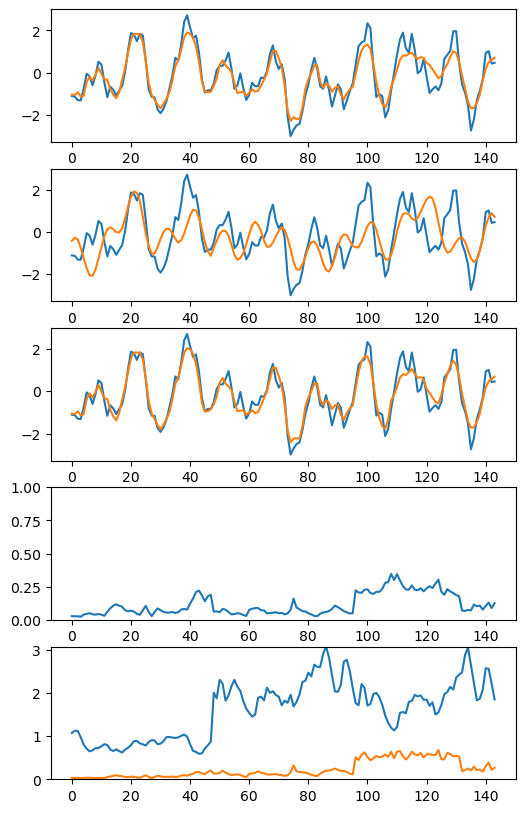

In [5]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        step = torch.arange(truth.shape[1]).reshape(-1, 1)

        model_output = model(back[[jdata]])
        blend = model_output[0]
        stat = model_output[1]
        trans = model_output[3]
        alpha = model_output[9]

        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        trans_uncertain = model_output[4]
        trans_uncertain = torch.exp(trans_uncertain) + 1e-6
        trans_uncertain_max = torch.max(trans_uncertain)
        trans_uncertain_max = 0.1 if trans_uncertain_max < 0.1 else trans_uncertain_max

        uncertain_max = stat_uncertain_max if stat_uncertain_max > trans_uncertain_max else trans_uncertain_max
        uncertain_max = 0.1 if uncertain_max < 0.1 else uncertain_max

        plt.figure(figsize=(6,10))

        plt.subplot(5,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(blend[0, :, :1])

        plt.subplot(5,1,2)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(5,1,3)
        plt.plot(truth[jdata, :, :1])
        plt.plot(trans[0, :, :1])

        plt.subplot(5,1,4)
        plt.plot(alpha[0, :, :1])
        plt.ylim((0., 1.))

        plt.subplot(5,1,5)
        plt.plot(stat_uncertain[0,:,:1])
        plt.plot(trans_uncertain[0,:,:1])
        plt.ylim((0., uncertain_max))

        plt.show()

        datasaved = False
        branch = 'stat'
        if datasaved:
            forecast_begin = model.args.lookback_nsample
            truth = truth[jdata, :, :1]
            blend = blend[0]
            stat = stat[0]
            trans = trans[0]
            alpha = alpha[0]
            stat_uncertain = stat_uncertain[0]
            trans_uncertain = trans_uncertain[0]

            savedata = np.expand_dims(np.concatenate([step, truth], axis=1), 0)
            utils_data.write_datafile(f'../../data/kalman/detuning_kind_{branch}_truth', savedata, delim=' ')

            savedata = np.expand_dims(np.concatenate([
                step[forecast_begin:],
                stat[forecast_begin:], trans[forecast_begin:], blend[forecast_begin:],
                stat_uncertain[forecast_begin:], trans_uncertain[forecast_begin:],
                alpha[forecast_begin:]], axis=1), 0)
            utils_data.write_datafile(f'../../data/kalman/detuning_kind_{branch}_forecast', savedata, delim=' ')

        break